# Train and fit SRV

# Overview
1. Use `TrajectoryDataset`, `VAMPNet`, `SRV` 
2. Verify `WeightedTrajectoryDataset`, `WeightedVAMPNet`, `WeightedSRV`

### For each
1. Load dataset
2. Train VAMPnet
3. Fit SRV

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from src.util import torch_device

device = torch_device()

PyTorch version: 2.9.1+cu130
CUDA version (PyTorch): 13.0
CUDA available: True
CUDA device count: 1
Using device=device(type='cuda')


# A. `TrajectoryDataset`, `VAMPNet`, `SRV`

## A.1 Load unbiased dataset

len(dataset) = 2999999


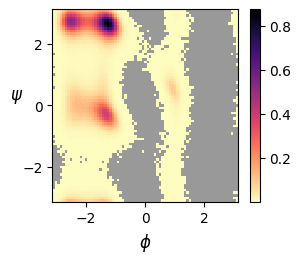

In [2]:
from src.param import param_unbiased_reference
from src.data import simulation_data
from src.dataset import TrajectoryDataset
from src.plots import plot_dihedrals_hist2d

p = param_unbiased_reference()
sd = simulation_data(p)
dataset = TrajectoryDataset(sd.features)

fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))
plot_dihedrals_hist2d(fig, ax, sd.dihedrals)
print(f"{len(dataset) = }")

## A.2 Train VAMPnet

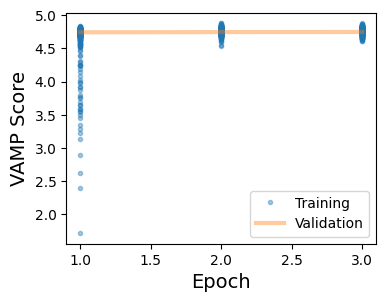

In [3]:
from src.dataset import data_loaders
from src.vampnet import vampnet
from tqdm.notebook import tqdm

calculate = False
if calculate:
    num_epochs = 3
    vn = vampnet(p, weighted=False)
    vn.fit(*data_loaders(dataset, p.frac_test), num_epochs=num_epochs, progress=tqdm)
    sd.save_and_assign_objects({"vampnet": vn})

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.plot(*sd.vampnet.train_scores.T, ".", alpha=0.4, label="Training")
ax.plot(*sd.vampnet.test_scores.T, "-", linewidth=3, alpha=0.4, label="Validation")
ax.set_xlabel("Epoch", fontsize=14)
ax.set_ylabel("VAMP Score", fontsize=14)
ax.legend()
fig.savefig("notes/figures/vampnet-training.png", bbox_inches="tight")

## A.3 Fit SRV

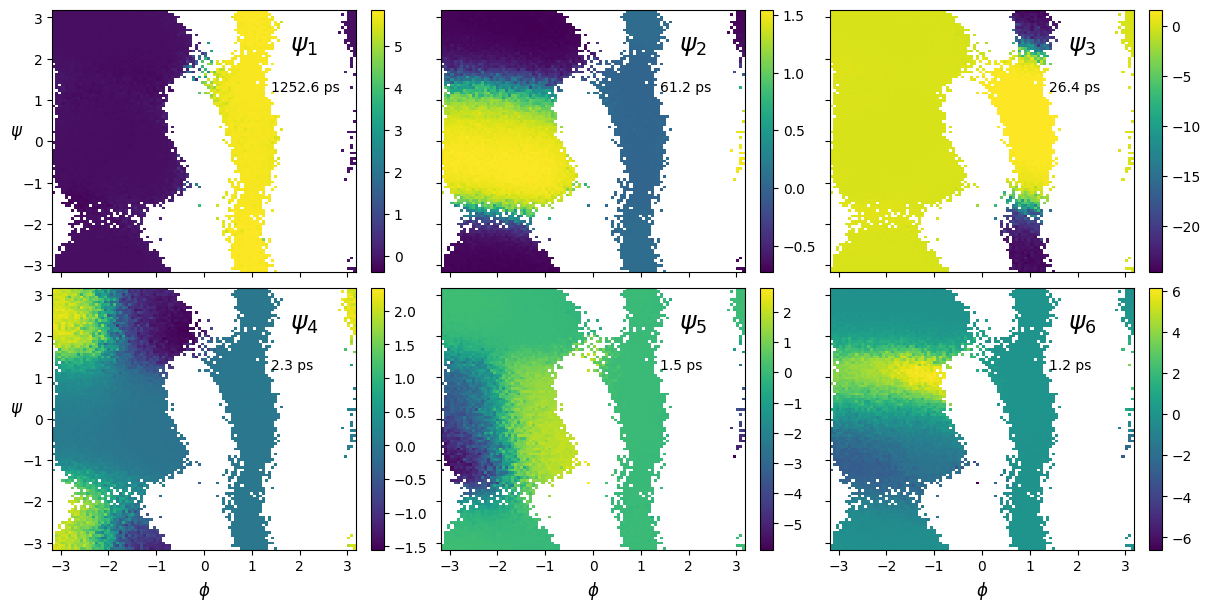

In [4]:
from src.vampnet import SRV
from src.plots import plot_eigfuncs

calculate = False
if calculate:
    srv = SRV(sd.vampnet.net, sd.lagtime)
    srv.fit(dataset)
    sd.save_eigen_data(srv)
    sd.save_grid_data(srv, num_points=100)

fig, axs = plt.subplots(
    2, 3, figsize=(12, 6), sharex=True, sharey=True, constrained_layout=True
)
plot_eigfuncs(fig, axs, sd.theta_grid, sd.psi_grid, sd.timescales)
fig.savefig("notes/figures/eigenfunctions.png", bbox_inches="tight")

cvs data ranges = [[np.float64(-1.9583668047852623), np.float64(7.413062087289325)], [np.float64(-1.3096040435974305), np.float64(2.122453656074453)]]


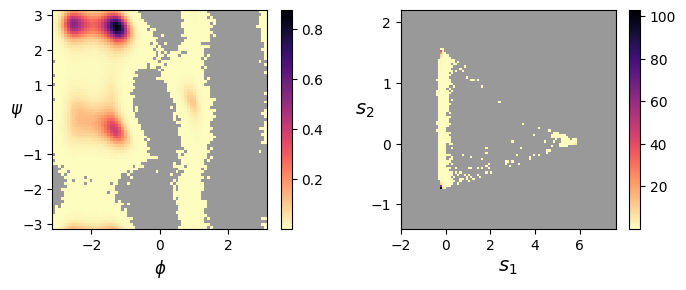

In [ ]:
from src.grid2d import ranges_data, grid1d_from_range, hist2d
from src.plots import plot_dihedrals_hist2d
from src.plots import plot_cvs_hist2d

print(f"cvs data ranges = {ranges_data(sd.cvs, pad=0.25)}")

x = grid1d_from_range([-2, 7.6])
y = grid1d_from_range([-1.4, 2.2])

fig, axs = plt.subplots(1, 2, figsize=(7, 3))
plot_dihedrals_hist2d(fig, axs[0], sd.dihedrals)
plot_cvs_hist2d(fig, axs[1], x, y, sd.cvs)
fig.tight_layout()
fig.savefig("notes/figures/unbiased-dih-cv-hist2d.png", bbox_inches="tight")

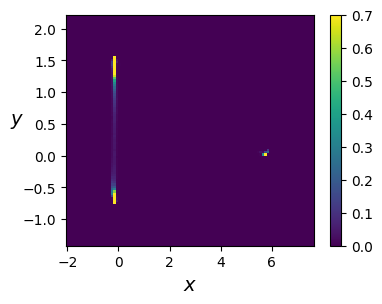

In [14]:
import importlib
import src.plots

importlib.reload(src.plots)

from src.grid2d import hist2d
from src.dataclass import data_class, DataClass
from src.plots import plot_histogram

pdf = data_class(
    sd.working_dir,
    "cvs_pdf",
    DataClass(x=x, y=y, p=hist2d(x, y, sd.cvs)),
)

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
cb = plot_histogram(ax, pdf.x, pdf.y, pdf.p, vmax=0.7)
plt.colorbar(cb, ax=ax)

# B. Verify `WeightedTrajectoryDataset`, `WeightedVAMPNet`, `WeightedSRV`

### B.1 Load data as weighted dataset (weights = $[1, 1, \ldots, 1]$)
* `simulation_data_test` = method to migrate symlinks to new directory and with `SimulationParameter` state.  Otherwise, workflow overwrites `VAMPnet` and `SRV`

In [12]:
from src.data import simulation_data_test
from src.dataset import WeightedTrajectoryDataset

sd2 = simulation_data_test(Path("data/verify-weighted"), sd, ["features", "dihedrals"])

dataset = WeightedTrajectoryDataset(sd2.features, np.ones(len(sd2.features)))

## B.2 Train VAMPnet

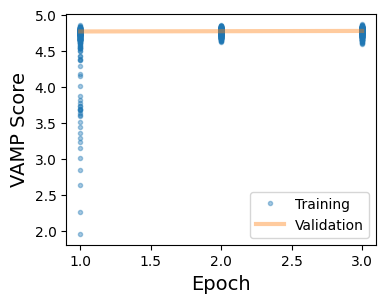

In [13]:
calculate = False
if calculate:
    num_epochs = 3
    vn = vampnet(p, weighted=True)
    vn.fit(*data_loaders(dataset, p.frac_test), num_epochs=num_epochs, progress=tqdm)
    sd2.save_and_assign_objects({"vampnet": vn})

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.plot(*sd2.vampnet.train_scores.T, ".", alpha=0.4, label="Training")
ax.plot(*sd2.vampnet.test_scores.T, "-", linewidth=3, alpha=0.4, label="Validation")
# ax.set_xticks(list(range(1, num_epochs + 1)))
ax.set_xlabel("Epoch", fontsize=14)
ax.set_ylabel("VAMP Score", fontsize=14)
ax.legend()
fig.savefig("notes/figures/vampnet-training-weighted.png", bbox_inches="tight")

## B.3 Fit SRV

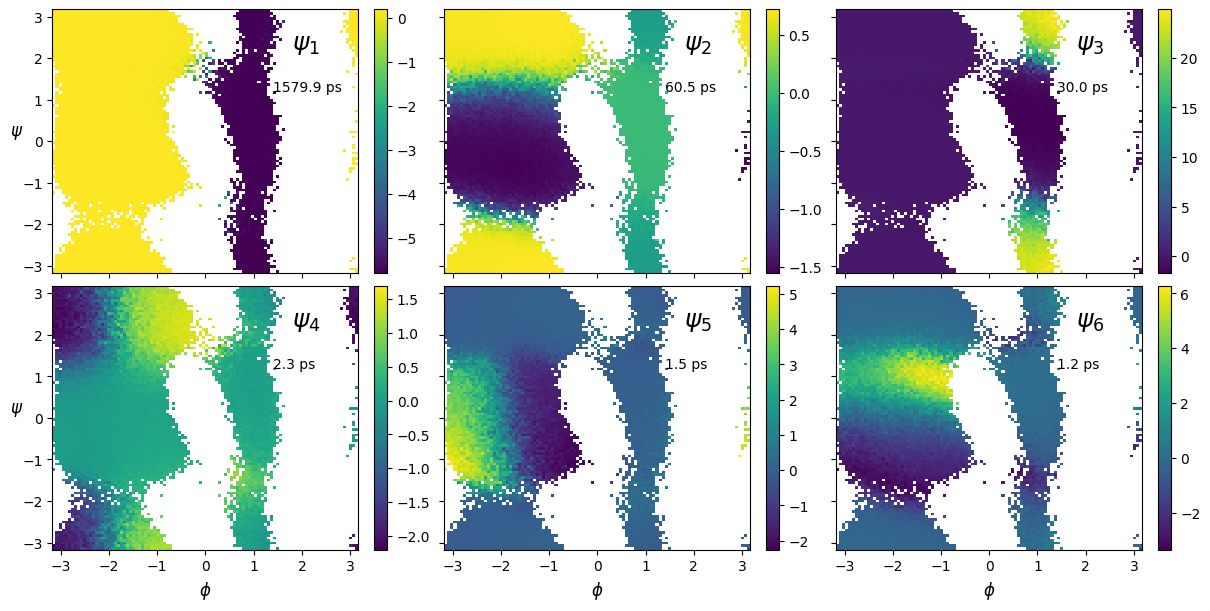

In [14]:
from src.vampnet import WeightedSRV

calculate = False
if calculate:
    srv = WeightedSRV(sd2.vampnet.net, sd2.lagtime)
    srv.fit(dataset)
    sd2.save_eigen_data(srv)
    sd2.save_grid_data(srv, num_points=100)

fig, axs = plt.subplots(
    2, 3, figsize=(12, 6), sharex=True, sharey=True, constrained_layout=True
)
plot_eigfuncs(fig, axs, sd2.theta_grid, sd2.psi_grid, sd2.timescales)
fig.savefig("notes/figures/eigenfunctions-weighted.png", bbox_inches="tight")